In [3]:
!pip install ucimlrepo

# **FASE 1   -  CARICAMENTO DATI**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import math
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [5]:
# ----------------------------
# A) CARICAMENTO DATASET
# ----------------------------
tennis = fetch_ucirepo(id=300)

X_raw = tennis.data.features
y_raw = tennis.data.targets

df_raw = pd.concat([X_raw, y_raw], axis=1)

# Controlli base
print("Shape df:", df_raw.shape)
print("\nInfo:")
print(df_raw.info())
df_raw.head()

Shape df: (943, 43)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 43 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tournament  943 non-null    object 
 1   Player1     943 non-null    object 
 2   Player2     943 non-null    object 
 3   Round       943 non-null    int64  
 4   FNL1        942 non-null    float64
 5   FNL2        942 non-null    float64
 6   FSP.1       943 non-null    int64  
 7   FSW.1       943 non-null    int64  
 8   SSP.1       943 non-null    int64  
 9   SSW.1       943 non-null    int64  
 10  ACE.1       921 non-null    float64
 11  DBF.1       935 non-null    float64
 12  WNR.1       817 non-null    float64
 13  UFE.1       817 non-null    float64
 14  BPC.1       942 non-null    float64
 15  BPW.1       942 non-null    float64
 16  NPA.1       859 non-null    float64
 17  NPW.1       860 non-null    float64
 18  TPW.1       631 non-null    float64
 19  ST

,Tournament,Player1,Player2,Round,FNL1,FNL2,FSP.1,FSW.1,SSP.1,SSW.1,...,BPW.2,NPA.2,NPW.2,TPW.2,ST1.2,ST2.2,ST3.2,ST4.2,ST5.2,Result
0,AusOpen-men,Lukas Lacko,Novak Djokovic,1,0.0,3.0,61,35,39,18,...,8.0,8.0,9.0,101.0,6.0,7.0,6.0,NaN,NaN,0
1,AusOpen-men,Leonardo Mayer,Albert Montanes,1,3.0,0.0,61,31,39,13,...,0.0,NaN,NaN,42.0,1.0,3.0,1.0,NaN,NaN,1
2,AusOpen-men,Marcos Baghdatis,Denis Istomin,1,0.0,3.0,52,53,48,20,...,13.0,12.0,16.0,126.0,6.0,7.0,6.0,NaN,NaN,0
3,AusOpen-men,Dmitry Tursunov,Michael Russell,1,3.0,0.0,53,39,47,24,...,7.0,NaN,NaN,79.0,2.0,2.0,3.0,NaN,NaN,1
4,AusOpen-men,Juan Monaco,Ernests Gulbis,1,1.0,3.0,76,63,24,12,...,5.0,16.0,28.0,127.0,1.0,6.0,7.0,6.0,NaN,0


# **FASE 2  - Ramo EDA su copia (analisi esplorativa)**

In [6]:
# ----------------------------
#  CREO COPIA PER EDA
# ----------------------------

df_eda = df_raw.copy()

# ----------------------------
#  SEPARO X e y
# ----------------------------

# Target
y_eda = df_eda["Result"]

# Features
X_eda = df_eda.drop(columns=["Result"])

In [7]:
# ----------------------------
#  Controllo missing values
# ----------------------------

# Missing values (top 20)
missing = X_eda.isnull().sum().sort_values(ascending=False)
print("\nTotale null: ", X_eda.isnull().sum().sum())
print("\nTop 20 colonne con più NaN:")
print(missing.head(20))


Totale null:  5338

Top 20 colonne con più NaN:
ST5.2    857
ST5.1    857
ST4.1    722
ST4.2    722
ST3.2    321
ST3.1    321
TPW.1    312
TPW.2    312
WNR.1    126
UFE.1    126
WNR.2    126
UFE.2    126
NPA.1     84
NPA.2     84
NPW.2     83
NPW.1     83
ACE.2     22
ACE.1     22
DBF.1      8
DBF.2      8
dtype: int64


In [8]:
# ----------------------------
#  Colonne categoriche (stringhe)
# ----------------------------

cat_cols = X_eda.select_dtypes(include=["object", "string"]).columns
num_cols = X_eda.select_dtypes(include=np.number).columns

print("Colonne categoriche:", list(cat_cols))
print("\nNumero colonne numeriche:", len(num_cols))
print("\nVecchia shape:", X_eda.shape)

# decisione didattica elimino le colonne categoriche
    # elimino Player1 / Player2 perche cosi evito il bias da identita.
    # Voglio che il modello impara statistiche e non che Federer = vittoria
    # elimino Tournament perche voglio modello basato su statistiche match
    # e non su dove si è svolto. È una semplificazione didattica.

X_eda = X_eda.drop(cat_cols, axis=1)
print("\nNuova shape:", X_eda.shape)

Colonne categoriche: ['Tournament', 'Player1', 'Player2']

Numero colonne numeriche: 39

Vecchia shape: (943, 42)

Nuova shape: (943, 39)


   Elimino le colonne

Colonna	Significato
ST1	    Set 1
ST2	    Set 2
ST3	    Set 3
ST4	    Set 4
ST5	    Set 5

--> Sono statistiche dei set  quindi  Null ≠ dato mancante ma Null = set non giocato
Decisione didattica: Eliminiamo tutte le colonne dei set perche troppi null e informazione già indiretta nel risultato

TPW (Total Points Won)

--> Totale punti vinti. È quasi il risultato della partita. Data leakage forte!
Eliminiamo anche TPW.

FNL1 / FNL2    Final score

--> data leakage. Contiene risultato match. Eliminiamo.

In [9]:
# Definisco le colonne da eliminare (Data Leakage + Target)
colonne_da_eliminare = [
    'ST1.1', 'ST1.2',         # Game set 1
    'ST2.1', 'ST2.2',         # Game set 2
    'ST3.1', 'ST3.2',         # Game set 3
    'ST4.1', 'ST4.2',         # Game set 4
    'ST5.1', 'ST5.2',         # Game set 5
    'TPW.1', 'TPW.2',         # Punti totali (troppo vicini al risultato)  leakage!!
    'FNL1',  'FNL2'           # Risultato finale set                       leakage!!
]
print("Vecchia shape:", X_eda.shape)

X_eda = X_eda.drop(colonne_da_eliminare, axis=1)

print("Features rimaste in X:")
print(X_eda.columns.tolist())
print("Nuova shape:", X_eda.shape)

Vecchia shape: (943, 39)
Features rimaste in X:
['Round', 'FSP.1', 'FSW.1', 'SSP.1', 'SSW.1', 'ACE.1', 'DBF.1', 'WNR.1', 'UFE.1', 'BPC.1', 'BPW.1', 'NPA.1', 'NPW.1', 'FSP.2', 'FSW.2', 'SSP.2', 'SSW.2', 'ACE.2', 'DBF.2', 'WNR.2', 'UFE.2', 'BPC.2', 'BPW.2', 'NPA.2', 'NPW.2']
Nuova shape: (943, 25)


In [10]:
# ---------------------------------
#  Controllo missing values rimasti
# ---------------------------------

# Missing values (top 20)
missing = X_eda.isnull().sum().sort_values(ascending=False)
print("\nTotale null: ", X_eda.isnull().sum().sum())
print("\nTop 20 colonne con più NaN:")
print(missing.head(20))


Totale null:  902

Top 20 colonne con più NaN:
WNR.1    126
UFE.1    126
WNR.2    126
UFE.2    126
NPA.1     84
NPA.2     84
NPW.2     83
NPW.1     83
ACE.1     22
ACE.2     22
DBF.1      8
DBF.2      8
BPC.1      1
BPW.2      1
BPW.1      1
BPC.2      1
Round      0
FSP.1      0
FSW.1      0
SSP.1      0
dtype: int64


   Gestisco i valori null

UFE - Unforced Errors
WNR

--> Winners
Null pochi (126 su dataset grande). Qui ha senso imputare.
Strategia: Media.

NPA / NPW  

--> Net Points Attempted / Won
Null pochi - imputazione media.

ACE / DBF

--> Ace e Doppi falli.
Null pochissimi - logico usare 0. Se non registrato - probabilmente 0

BPC	- Break Points Created

BPW	- Break Points Won

-->
Strategia: Media imputazione perché dataset grande, pochi null e variabile continua


In [11]:
# Media imputazione
for col in ["UFE.1","UFE.2","WNR.1","WNR.2",
            "NPA.1","NPA.2","NPW.1","NPW.2",
            "BPC.1","BPW.1","BPC.2","BPW.2"]:
    X_eda[col] = X_eda[col].fillna(X_eda[col].mean())

# Zero imputazione
for col in ["ACE.1","ACE.2","DBF.1","DBF.2"]:
        X_eda[col] = X_eda[col].fillna(0)

print("\nTotale null: ", X_eda.isnull().sum().sum())


Totale null:  0


#   Grafici EDA

Boxplot per classe (Result=0 vs Result=1)
                    
Serve per verificare se:
    La mediana (linea nel box) è diversa tra 0 e 1?
    I box sono separati o sovrapposti?
    Una classe ha valori molto più alti?

Se sì → quella feature distingue bene le classi e quindi aiuta a prevedere Result

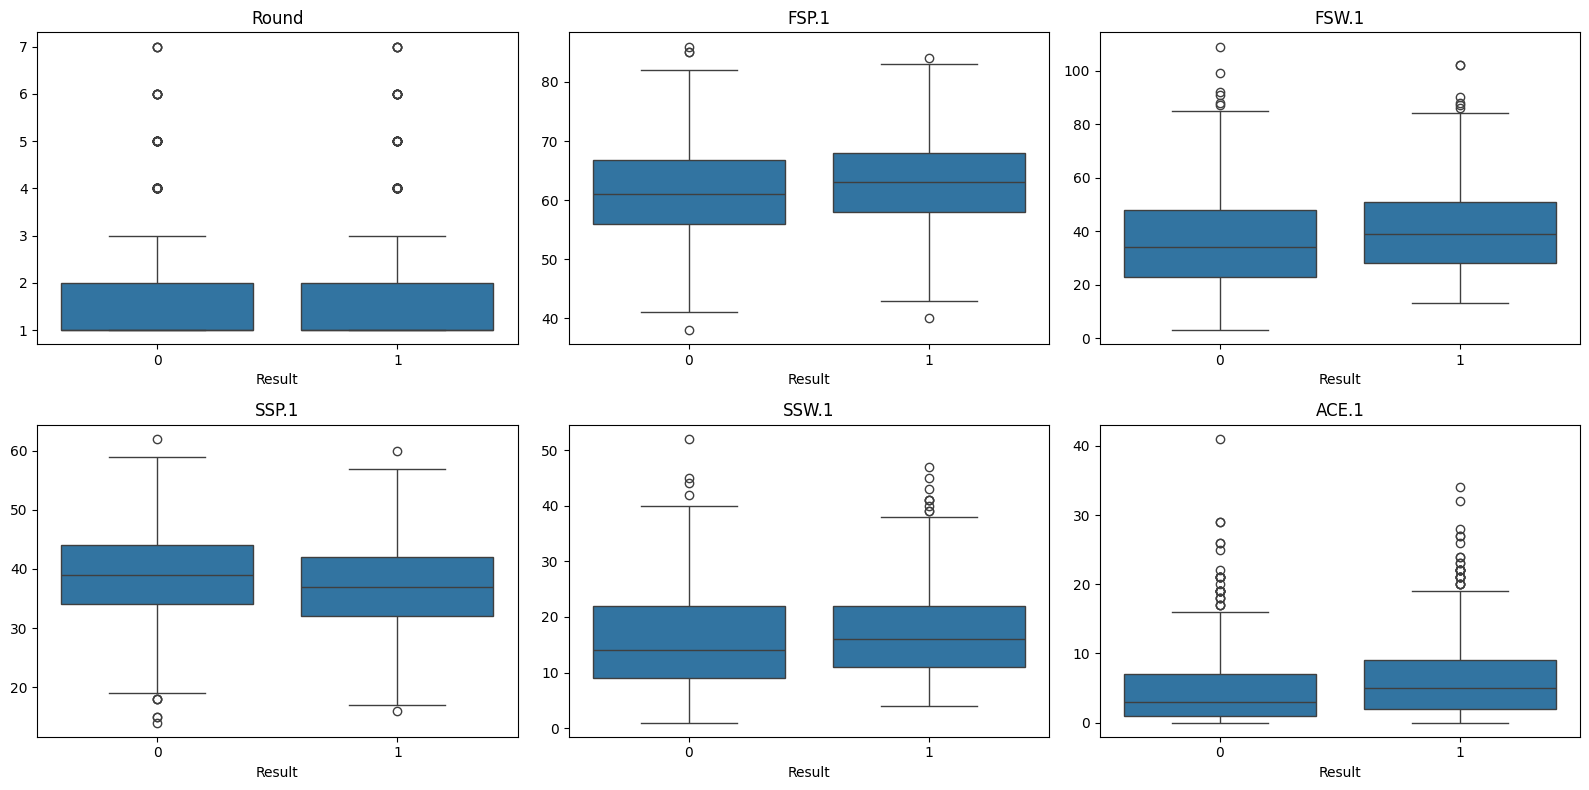

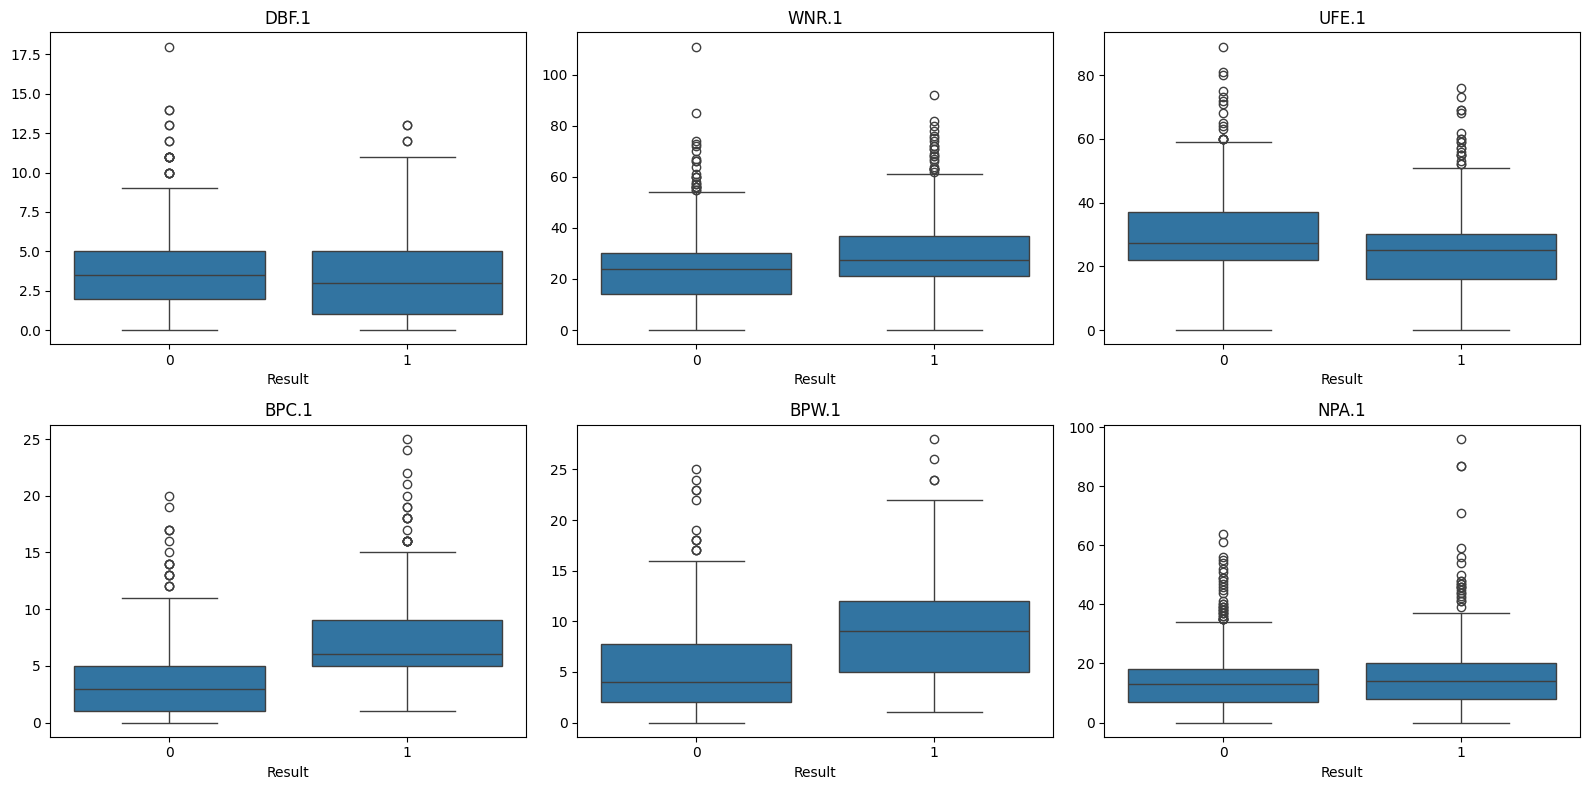

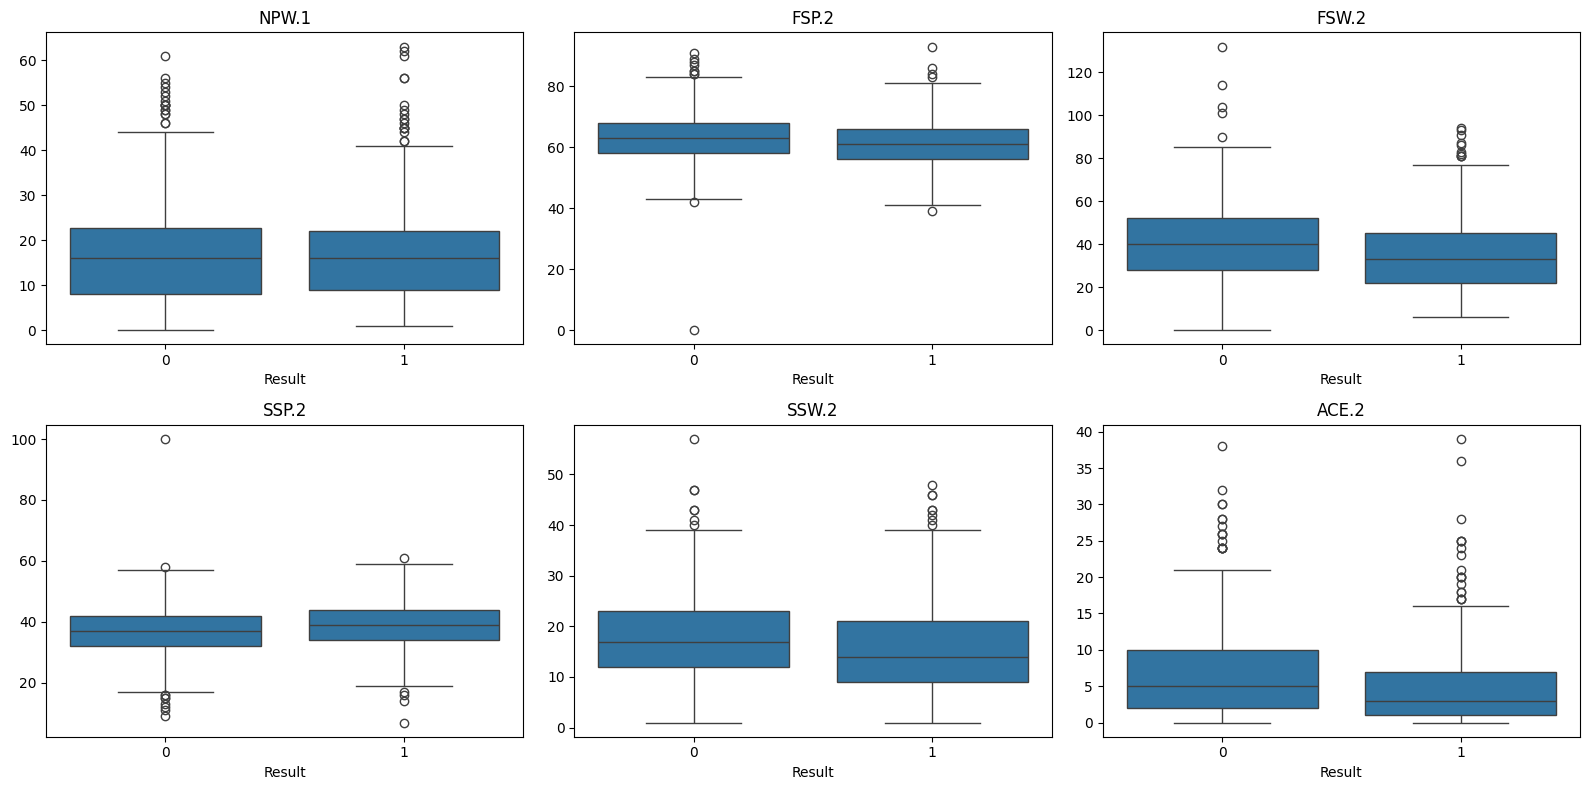

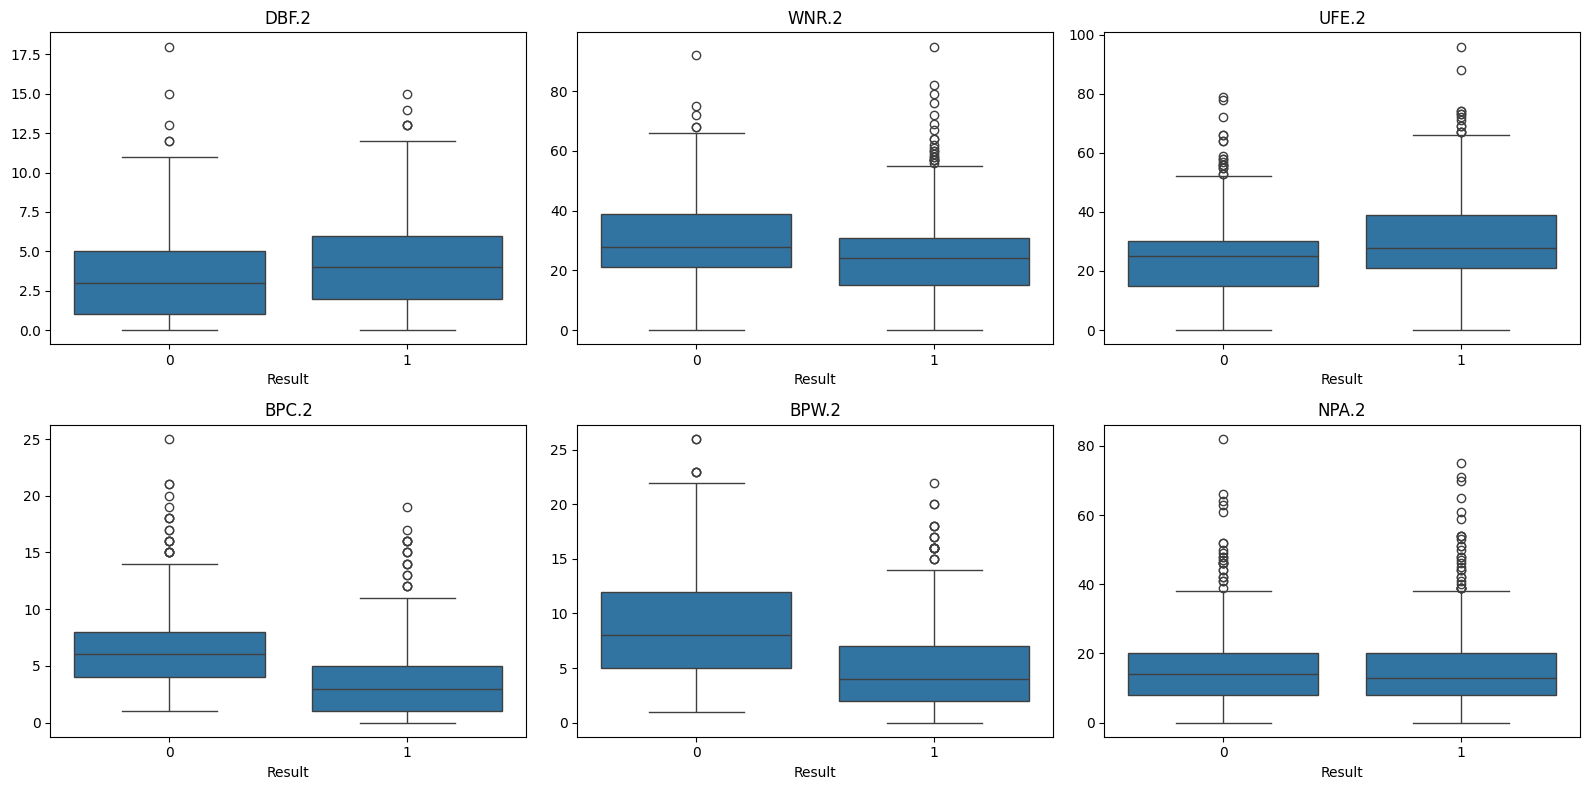

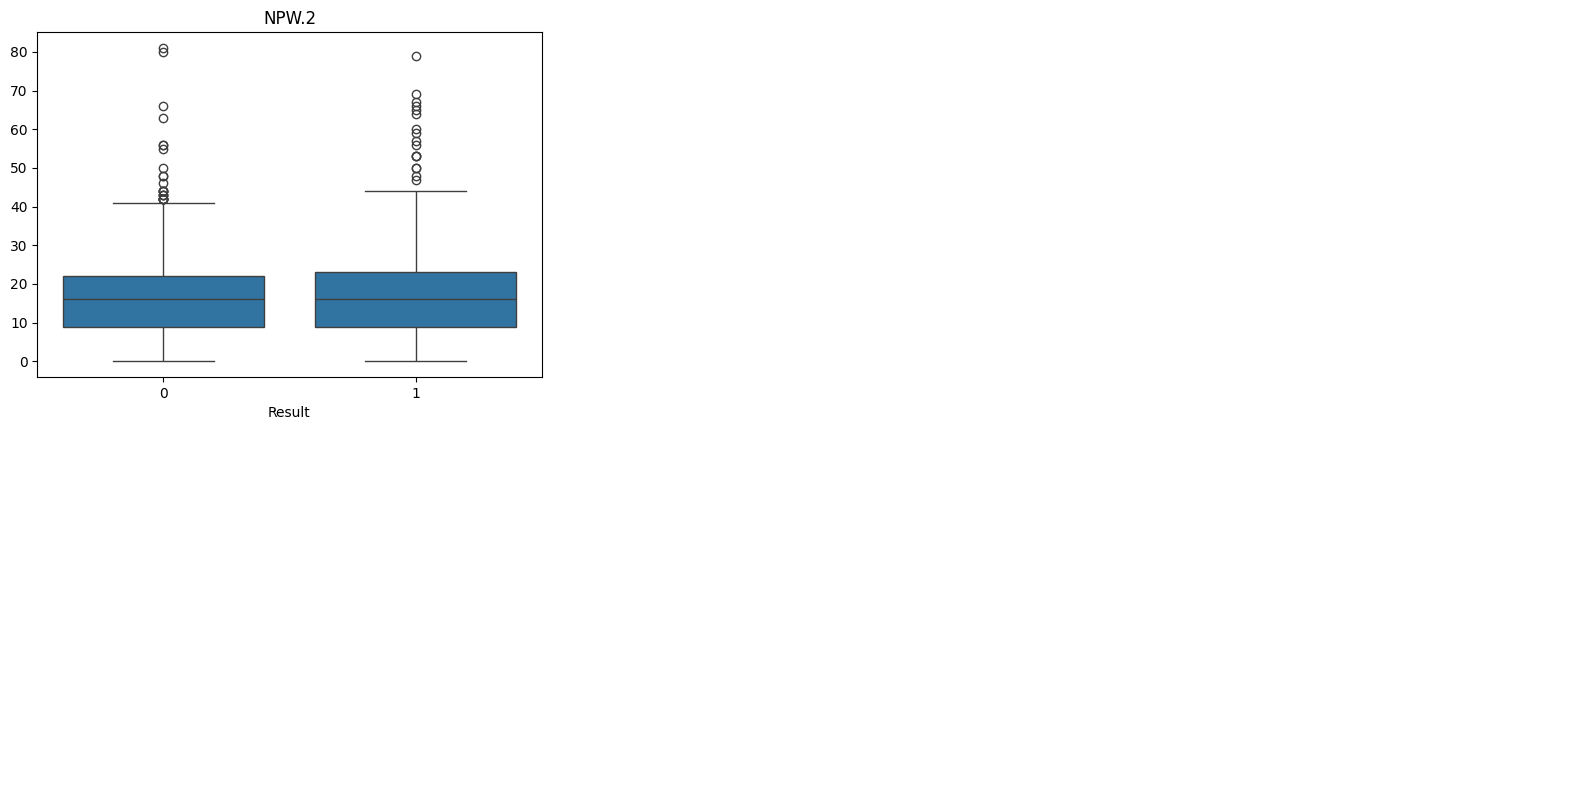

In [12]:
# unisco per i boxplot

df_plot = X_eda.copy()
df_plot["Result"] = y_eda

cols = [c for c in df_plot.columns if c != "Result"]

per_fig = 6
n_fig = math.ceil(len(cols) / per_fig)

for f in range(n_fig):
    subset = cols[f*per_fig:(f+1)*per_fig]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()

    for ax, col in zip(axes, subset):
        sns.boxplot(data=df_plot, x="Result", y=col, ax=ax)
        ax.set_title(col)
        ax.set_xlabel("Result")
        ax.set_ylabel("")

    for ax in axes[len(subset):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

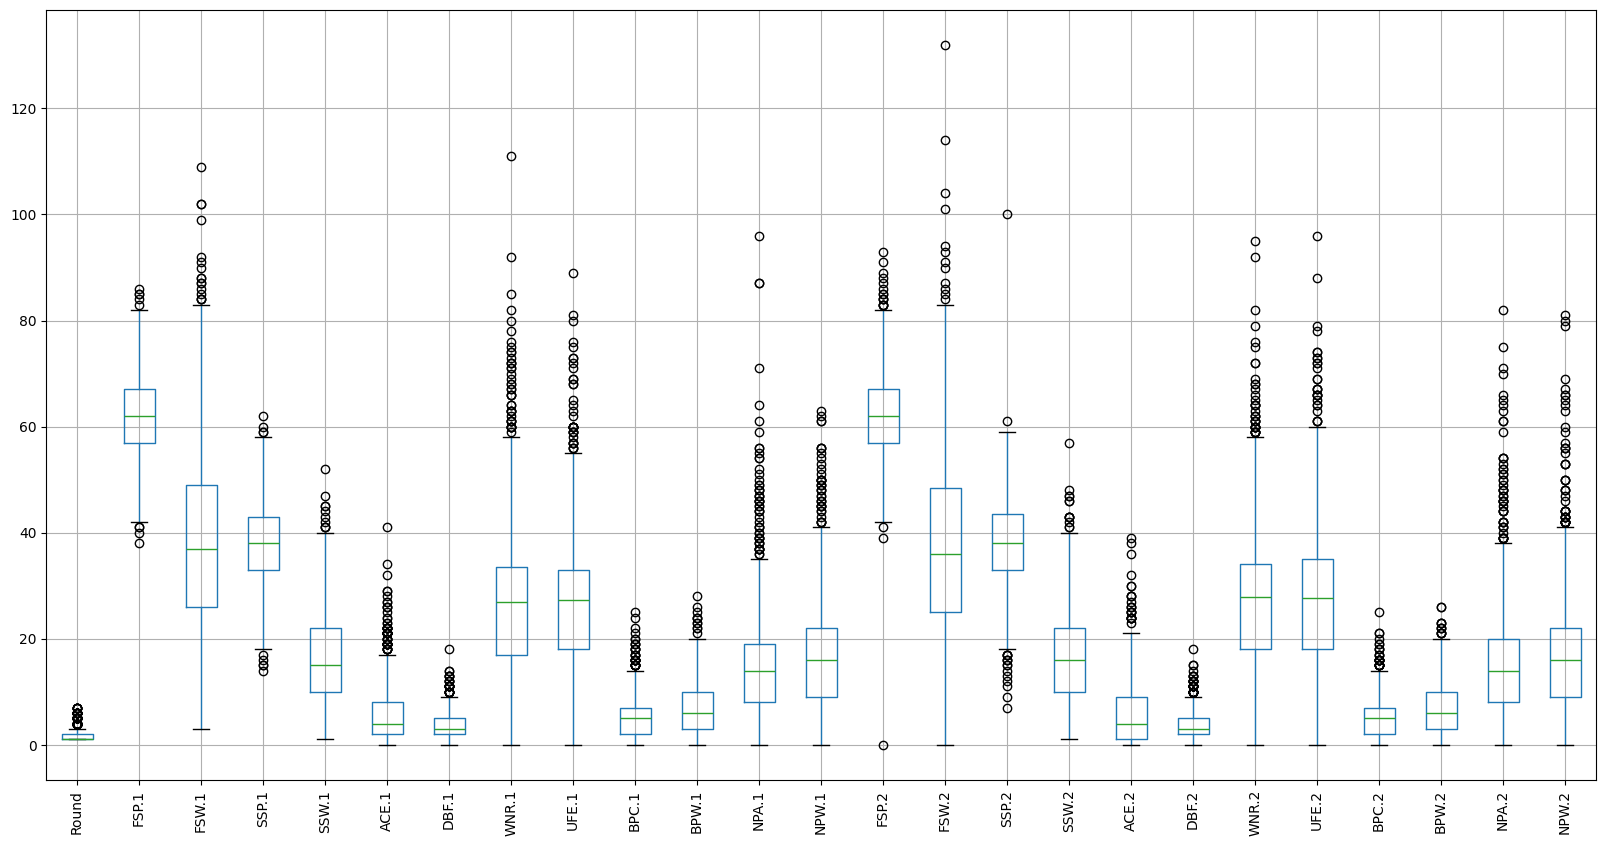

In [13]:
plt.figure(figsize=(20,10))
X_eda.boxplot()
plt.xticks(rotation=90)
plt.show()

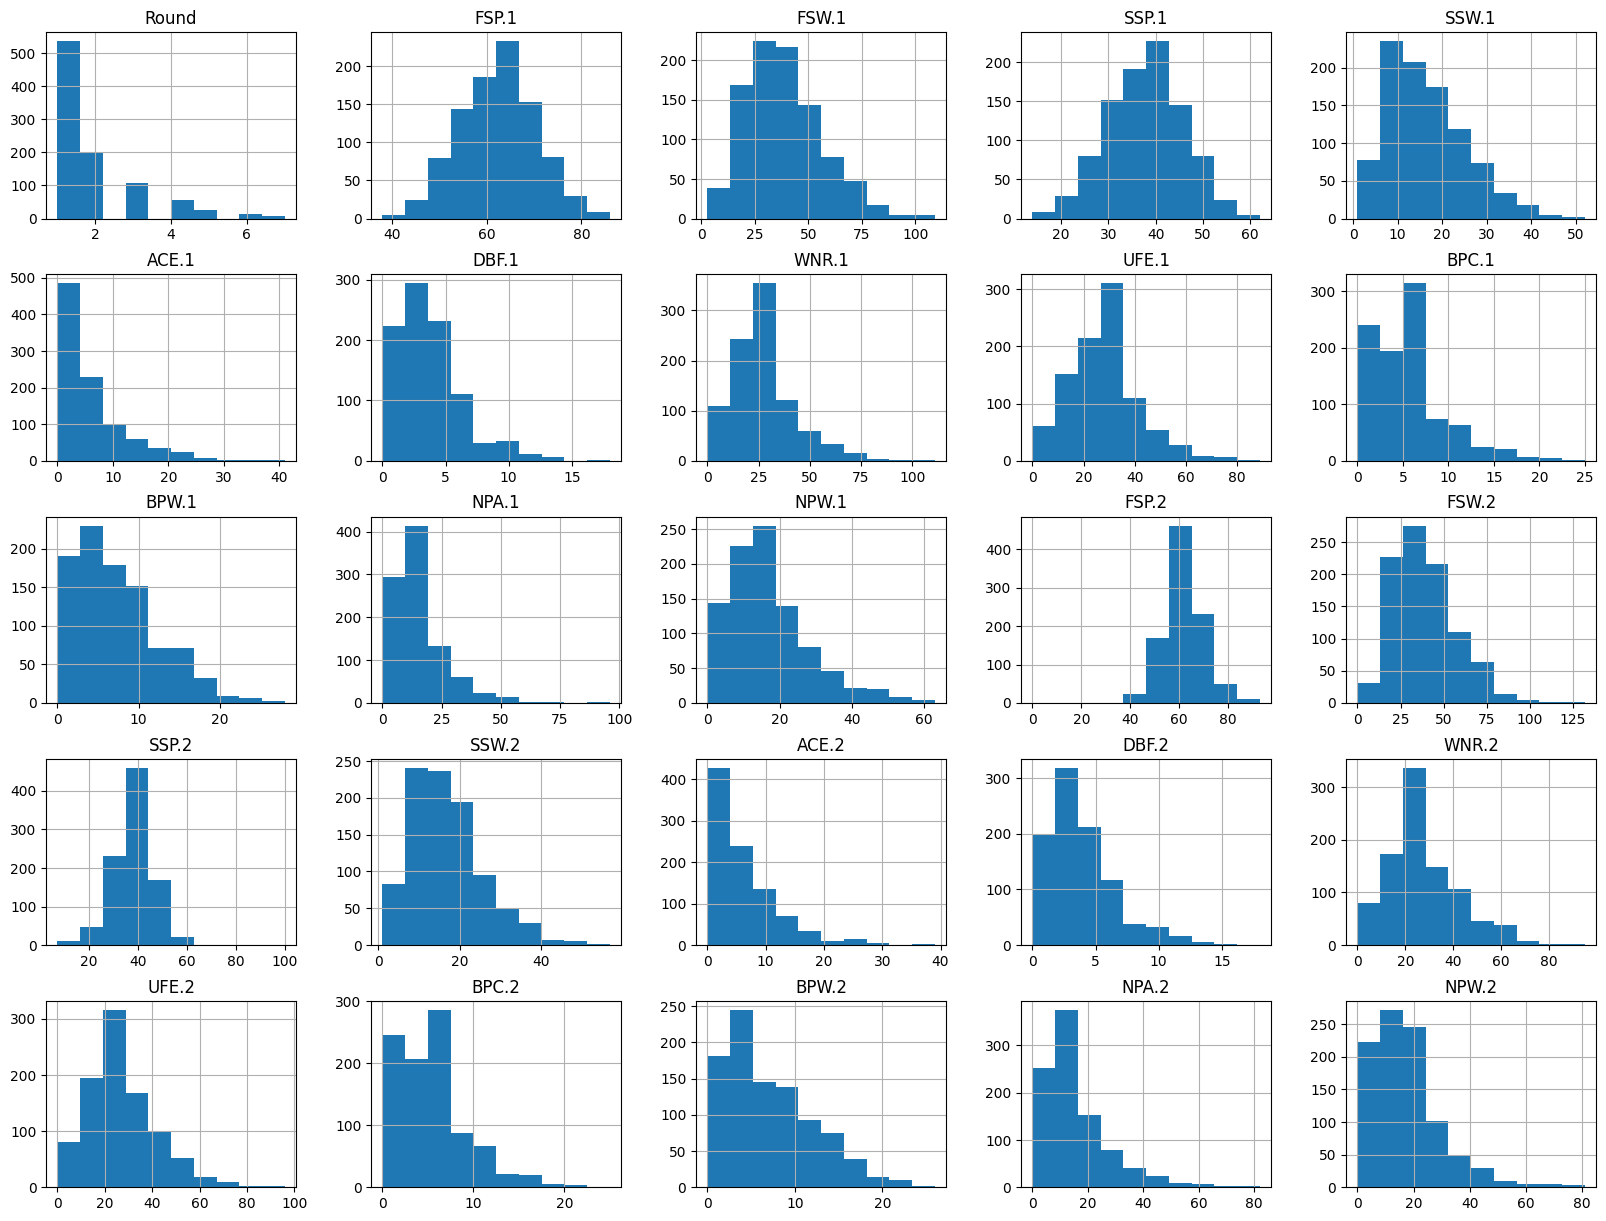

In [45]:
X_eda.hist(figsize=(20,15))
plt.show()

In [14]:
# ----------------------------
# correlazioni featurs e target
# ----------------------------

df_numeric = df_plot.select_dtypes(include=np.number)

corr_target = df_numeric.corr()['Result'].sort_values(ascending=False)

print("\nCorrelazione (imputazione globale SOLO EDA) ", corr_target)


Correlazione (imputazione globale SOLO EDA)  Result    1.000000
BPC.1     0.462285
BPW.1     0.395337
UFE.2     0.192133
WNR.1     0.187556
ACE.1     0.161881
DBF.2     0.160631
FSP.1     0.121533
FSW.1     0.117916
SSP.2     0.094126
SSW.1     0.074887
NPA.1     0.043827
NPW.2     0.015697
Round     0.007591
NPW.1     0.007217
NPA.2    -0.011358
FSP.2    -0.094218
SSP.1    -0.118842
SSW.2    -0.121330
DBF.1    -0.145305
FSW.2    -0.167057
ACE.2    -0.169011
UFE.1    -0.169722
WNR.2    -0.181228
BPW.2    -0.390047
BPC.2    -0.424214
Name: Result, dtype: float64




# **FASE 3 — Decisioni di preprocessing**
##  RAMO TRAINING (pipeline corretta)
Qui faccio:
1) decido cosa togliere (categoriche + leakage)
2) split train/val/test
3) preprocessing con ColumnTransformer (mean + zero) + StandardScaler, fit solo su train
4) modelli classici + rete neurale

In [15]:
# ----------------------------
#  CREO COPIA PER TRAINING
# ----------------------------

#  Parto dal RAW (non dalla copia imputata EDA)
df = df_raw.copy()

y = df["Result"]
X = df.drop(columns=["Result"])

# ----------------------------
#  RIMOZIONE COLONNE CATEGORICHE
# ----------------------------

# 1) Drop categoriche (scelta didattica)
cat_cols = X.select_dtypes(include=["object", "string"]).columns
X = X.drop(columns=cat_cols)

# 2) Drop leakage (se colonne presenti)
leak_cols = [
    'ST1.1', 'ST1.2',
    'ST2.1', 'ST2.2',
    'ST3.1', 'ST3.2',
    'ST4.1', 'ST4.2',
    'ST5.1', 'ST5.2',
    'TPW.1', 'TPW.2',
    'FNL1',  'FNL2'
]
leak_present = [c for c in leak_cols if c in X.columns]
X = X.drop(columns=leak_present)

print("Shape X dopo drop:", X.shape)

Shape X dopo drop: (943, 25)


# **FASE 4 — Split**

In [16]:
# ----------------------------
#  SPLIT train/val/test
# ----------------------------

# 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 20% di (train+val) diventa val -> 0.15 del temp = 0.2 totale
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15,
    random_state=42,
    stratify=y_temp
)

print("\nTrain:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (640, 25) Val: (114, 25) Test: (189, 25)


# **FASE 5 — Preprocessing statistico**  (imputazione mista + scaling)

In [17]:
# Controllo missing values

# print(X.isnull().sum().sort_values(ascending=False))
print("\nTotale null: ", X.isnull().sum().sum())


Totale null:  902


In [18]:
# ----------------------------
#  PREPROCESSING: imputazione + scaling
# ----------------------------

zero_cols = ["ACE.1","ACE.2","DBF.1","DBF.2"]

mean_cols = [col for col in X.columns if col not in zero_cols]

  VERSIONE 1

In [19]:
# 1) Imputazione: media
mean_imputer = SimpleImputer(strategy="mean")

# FIT solo su train
X_train_mean = mean_imputer.fit_transform(X_train[mean_cols])
X_val_mean   = mean_imputer.transform(X_val[mean_cols])
X_test_mean  = mean_imputer.transform(X_test[mean_cols])

# Per le colonne zero
X_train_zero = X_train[zero_cols].fillna(0).values
X_val_zero   = X_val[zero_cols].fillna(0).values
X_test_zero  = X_test[zero_cols].fillna(0).values

# Ricompongo il dataset
X_train_imp = np.hstack([X_train_mean, X_train_zero])
X_val_imp   = np.hstack([X_val_mean,   X_val_zero])
X_test_imp  = np.hstack([X_test_mean,  X_test_zero])


# 2) Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)

n_features = X_train_scaled.shape[1]
print("\nNumero feature finali:", n_features)
print("Shape dopo preprocessing:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)



Numero feature finali: 25
Shape dopo preprocessing: (640, 25) (114, 25) (189, 25)


VERSIONE 2

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("mean_imp", SimpleImputer(strategy="mean"), mean_cols),
        ("zero_imp", SimpleImputer(strategy="constant", fill_value=0), zero_cols)
    ]
)

# Preprocessing per alberi

pipeline_tree = Pipeline([
    ("imputer", preprocessor)   # senza scaler
])

# Preprocessing per modelli lineari e NN

pipeline_scaled = Pipeline([
    ("imputer", preprocessor),
    ("scaler", StandardScaler())
])

# Fit solo su train
X_train_tree = pipeline_tree.fit_transform(X_train)
X_val_tree   = pipeline_tree.transform(X_val)
X_test_tree  = pipeline_tree.transform(X_test)

# Fit solo su train
X_train_scaled = pipeline_scaled.fit_transform(X_train)
X_val_scaled   = pipeline_scaled.transform(X_val)
X_test_scaled  = pipeline_scaled.transform(X_test)

print("Shape dopo preprocessing:", X_train_tree.shape, X_val_tree.shape, X_test_tree.shape)


Shape dopo preprocessing: (640, 25) (114, 25) (189, 25)


# **FASE 6 — Modelli classici**  (sklearn)

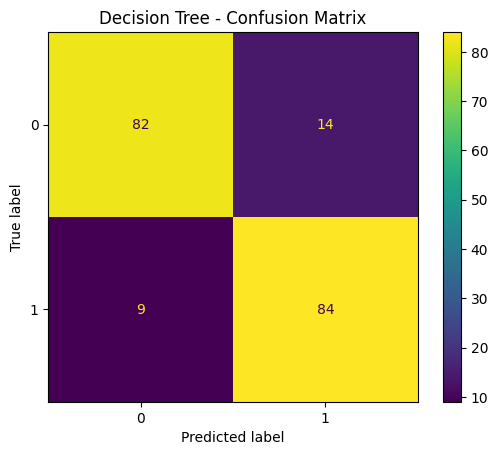

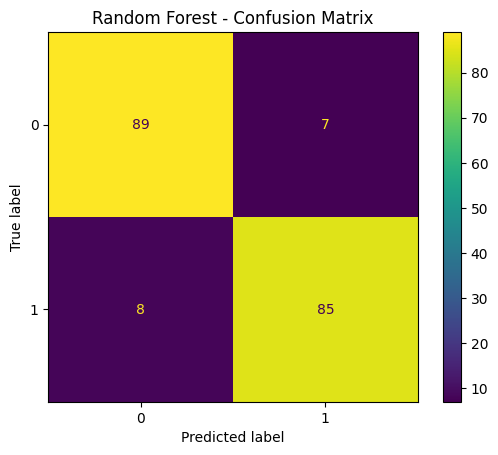

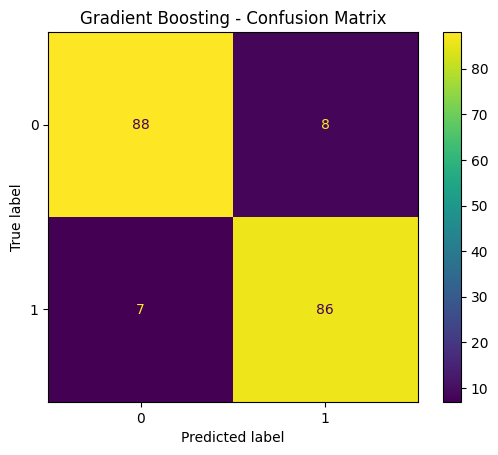

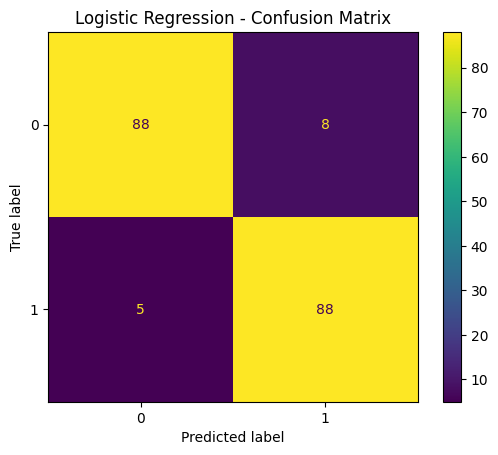

,model,accuracy,auc
3,LogisticRegression,0.931217,0.984543
2,GradientBoosting,0.920635,0.979615
1,RandomForest,0.920635,0.976759
0,DecisionTree,0.878307,0.878696


In [36]:
from sklearn.metrics import precision_recall_curve, auc

# Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_tree, y_train)
tree_proba = tree.predict_proba(X_test_tree)[:, 1]
tree_pred = (tree_proba > 0.5).astype(int)

cm_tree = confusion_matrix(y_test, tree_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_tree, y_train)
rf_proba = rf.predict_proba(X_test_tree)[:, 1]
rf_pred = (rf_proba > 0.5).astype(int)

cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
gb.fit(X_train_tree, y_train)
gb_proba = gb.predict_proba(X_test_tree)[:, 1]
gb_pred = (gb_proba > 0.5).astype(int)

cm_gb = confusion_matrix(y_test, gb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp.plot()
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

# Logistic Regression
log = LogisticRegression(max_iter=2000)
log.fit(X_train_scaled, y_train)
log_proba = log.predict_proba(X_test_scaled)[:, 1]
log_pred = (log_proba > 0.5).astype(int)

cm_log = confusion_matrix(y_test, log_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

def metrics_binary(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    return {"model": name, "accuracy": acc, "auc": auc}

results = []
results.append(metrics_binary("DecisionTree", y_test, tree_pred, tree_proba))
results.append(metrics_binary("RandomForest", y_test, rf_pred, rf_proba))
results.append(metrics_binary("GradientBoosting", y_test, gb_pred, gb_proba))
results.append(metrics_binary("LogisticRegression", y_test, log_pred, log_proba))

pd.DataFrame(results).sort_values(by="auc", ascending=False)


# Feature Importance - Random Forest

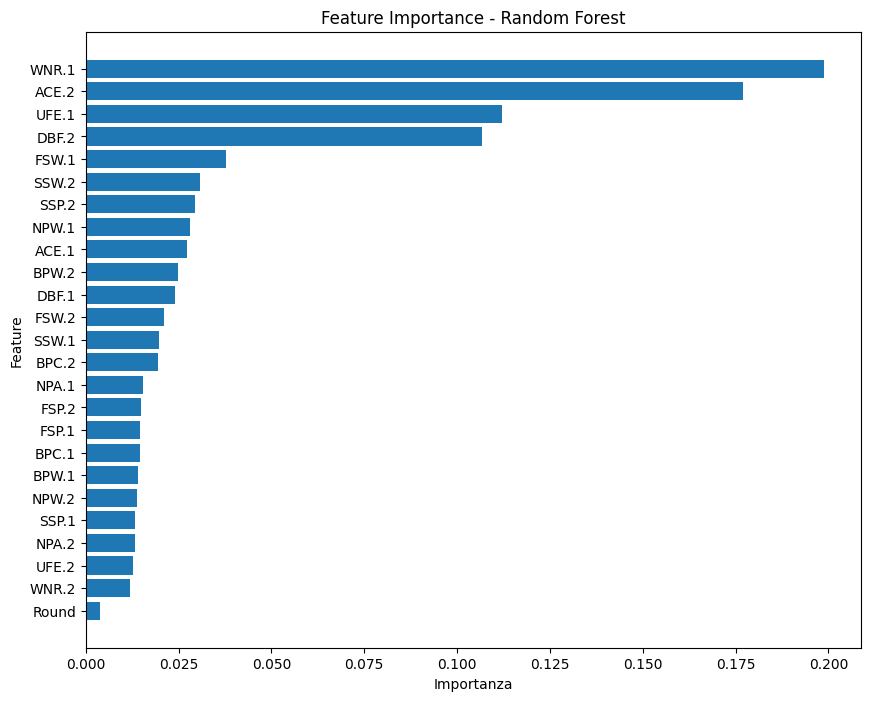

In [31]:
#    Estrazione Feature Importance

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Grafico Feature Importance

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importanza")
plt.ylabel("Feature")
plt.show()

# Feature Importance — Logistic Regression

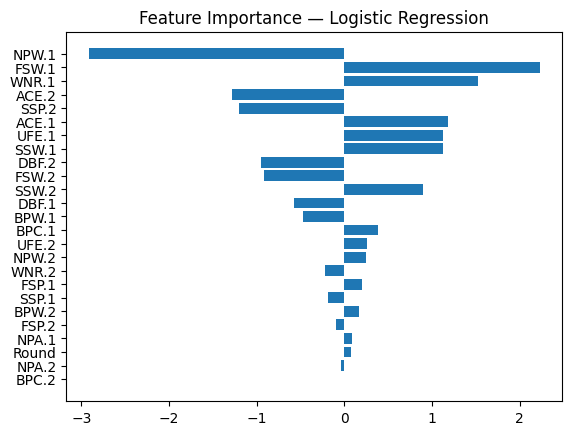

/tmp/ipython-input-720466771.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefs, palette=colors)


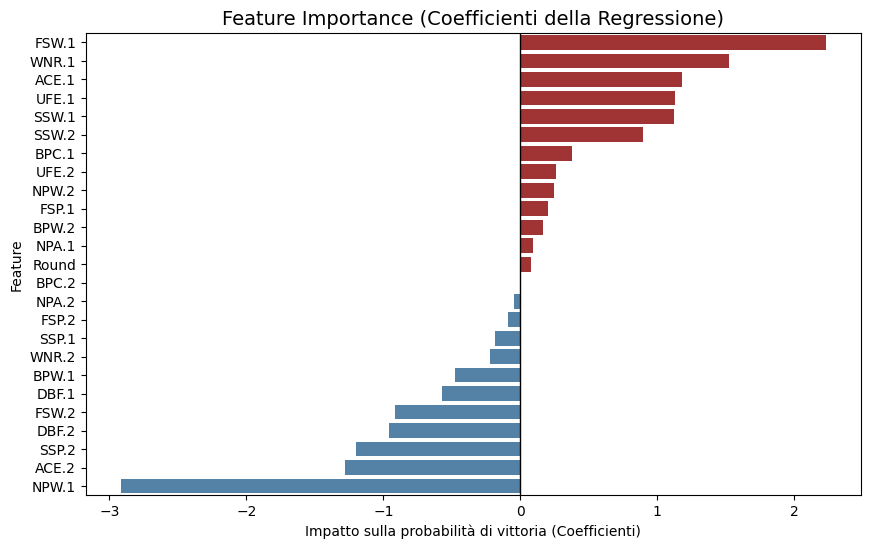

In [51]:
coef = log.coef_[0]

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coef
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.barh(importance_df["Feature"], importance_df["Coefficient"])
plt.gca().invert_yaxis()
plt.title("Feature Importance — Logistic Regression")
plt.show()

# Usiamo un barplot classico: Rosso = Aiuta P1, Blu = Aiuta P2
coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['firebrick' if x > 0 else 'steelblue' for x in coefs['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=coefs, palette=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title("Feature Importance (Coefficienti della Regressione)", fontsize=14)
plt.xlabel("Impatto sulla probabilità di vittoria (Coefficienti)")
plt.legend([],[], frameon=False)
plt.show()

# **FASE 7 — Rete neurale (Keras)**
Usa gli stessi dati preprocessati (X_train_slaled, X_val_scaled, X_test_scaled).

Keras vuole numpy array

In [22]:

y_train_np = np.array(y_train)
y_val_np   = np.array(y_val)
y_test_np  = np.array(y_test)

n_features = X_train_scaled.shape[1]

nn = Sequential([
    Input(shape=(n_features,)),
    Dense(8, activation="relu"),
    # Dense(2, activation="relu"),
    Dense(1, activation="sigmoid")
])

nn.compile(
    optimizer=SGD(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="best_tennis_nn.keras",
    monitor="val_loss",
    save_best_only=True
)

history = nn.fit(
    X_train_scaled, y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=200,
    batch_size=15,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

test_loss, test_acc = nn.evaluate(X_test_scaled, y_test_np, verbose=0)
print("NN test_loss:", test_loss)
print("NN test_acc :", test_acc)

best_nn = load_model("best_tennis_nn.keras")
nn_proba = best_nn.predict(X_test_scaled, verbose=0).reshape(-1)   # un vettore 1D di probabilità
nn_pred = (nn_proba > 0.5).astype(int)

nn_auc = roc_auc_score(y_test_np, nn_proba)
print("NN AUC:", nn_auc)


Epoch 1/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4910 - loss: 0.8661 - val_accuracy: 0.5965 - val_loss: 0.6408
Epoch 2/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6549 - loss: 0.6295 - val_accuracy: 0.7456 - val_loss: 0.5605
Epoch 3/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7539 - loss: 0.5467 - val_accuracy: 0.7982 - val_loss: 0.4971
Epoch 4/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8479 - loss: 0.4615 - val_accuracy: 0.8070 - val_loss: 0.4476
Epoch 5/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8831 - loss: 0.4177 - val_accuracy: 0.8421 - val_loss: 0.4069
Epoch 6/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9083 - loss: 0.3535 - val_accuracy: 0.8509 - val_loss: 0.3724
Epoch 7/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8997 - loss: 0.3407 - val_accuracy: 0.8684 - val_loss: 0.3467
Epoch 8/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9248 - loss: 0.2796 - val_accuracy: 0.8860 - 

In [23]:

# Aggiungo NN alla tabella risultati
results.append(metrics_binary("NeuralNetwork(Keras)", y_test_np, nn_pred, nn_proba))
pd.DataFrame(results).sort_values(by="auc", ascending=False)


,model,accuracy,auc
3,LogisticRegression,0.931217,0.984543
2,GradientBoosting,0.920635,0.979615
4,NeuralNetwork(Keras),0.941799,0.979503
1,RandomForest,0.920635,0.976759
0,DecisionTree,0.878307,0.878696


##  Confronto ROC curve (tutti i modelli)

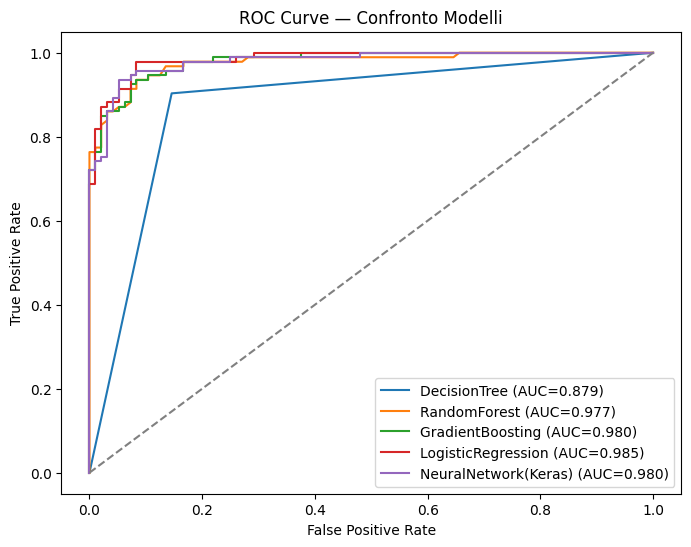

In [24]:

plt.figure(figsize=(8,6))

for name, proba in [
    ("DecisionTree", tree_proba),
    ("RandomForest", rf_proba),
    ("GradientBoosting", gb_proba),
    ("LogisticRegression", log_proba),
    ("NeuralNetwork(Keras)", nn_proba),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Confronto Modelli")
plt.legend()
plt.show()


##  Confronto Precision–Recall curve (tutti i modelli)

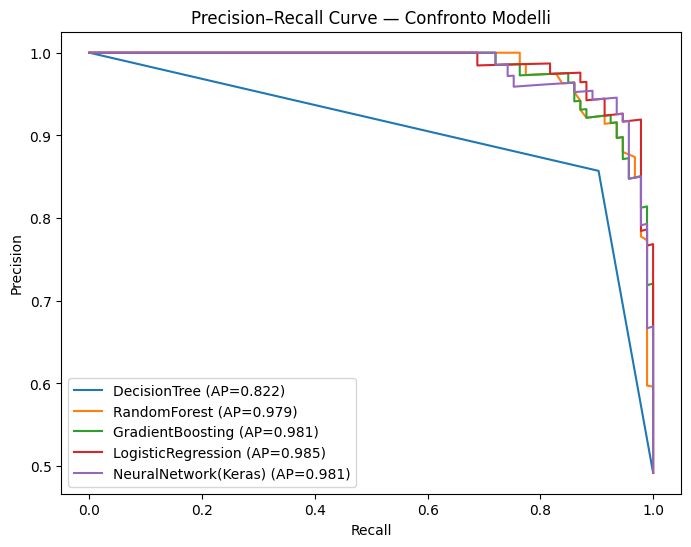

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for name, proba in [
    ("DecisionTree", tree_proba),
    ("RandomForest", rf_proba),
    ("GradientBoosting", gb_proba),
    ("LogisticRegression", log_proba),
    ("NeuralNetwork(Keras)", nn_proba),
]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)  # AP standard
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Confronto Modelli")
plt.legend()
plt.show()

## Grafici training NN (loss/accuracy)

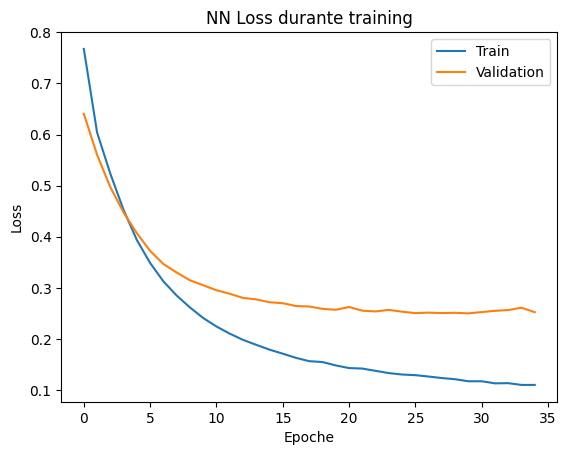

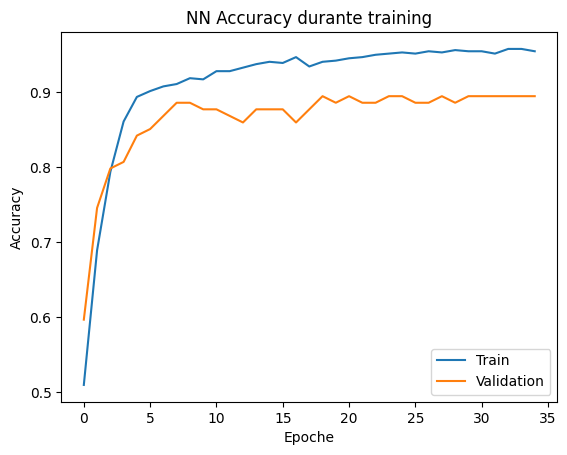

In [25]:

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("NN Loss durante training")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("NN Accuracy durante training")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


# VISUALIZZAZIONE ALBERO DECISIONALE

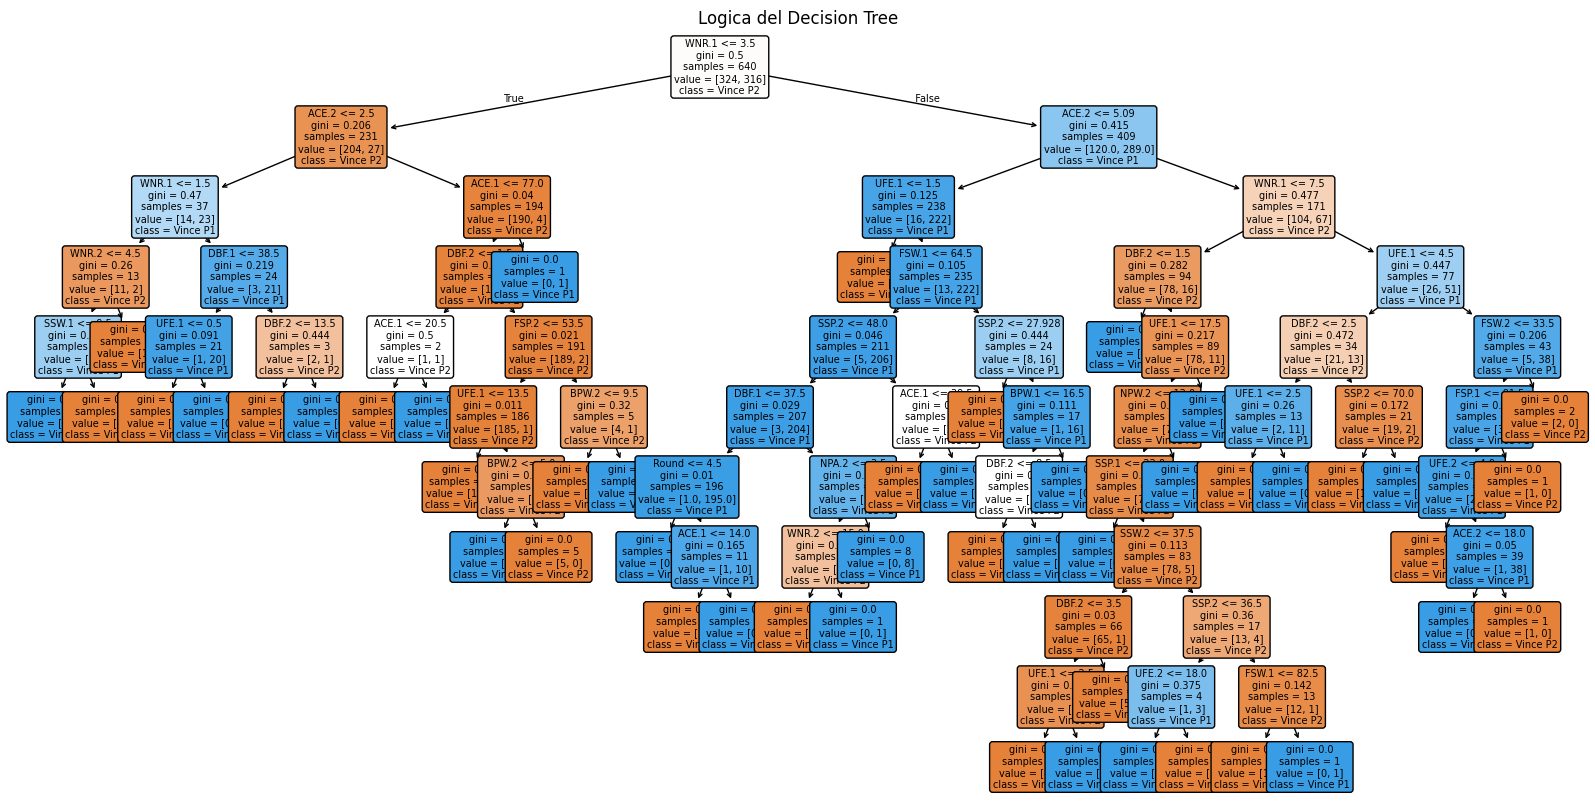

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree,
          feature_names=X_train.columns,
          class_names=['Vince P2', 'Vince P1'],
          filled=True,
          rounded=True,
          fontsize=7)
plt.title("Logica del Decision Tree")
plt.show()

# Tabella Confronto Finale

In [35]:
# ----------------------------
# Calcolo metriche
# ----------------------------
results = []

for name, pred, proba in [
    ("DecisionTree", tree_pred, tree_proba),
    ("RandomForest", rf_pred, rf_proba),
    ("GradientBoosting", gb_pred, gb_proba),
    ("LogisticRegression", log_pred, log_proba),
    ("NeuralNetwork(Keras)", nn_pred, nn_proba),
]:

    acc = accuracy_score(y_test, pred)
    auc_roc = roc_auc_score(y_test, proba)
    ap_pr = average_precision_score(y_test, proba)

    results.append([name, acc, auc_roc, ap_pr])


# ----------------------------
# Creo DataFrame
# ----------------------------
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "AUC_ROC", "AP_PR"]
)

# Ordino per AUC_ROC (facoltativo)
results_df = results_df.sort_values(by="AUC_ROC", ascending=False)

print("\n Confronto Finale Modelli \n")
print(results_df)


=== Confronto Finale Modelli ===

                  Model  Accuracy   AUC_ROC     AP_PR
3    LogisticRegression  0.931217  0.984543  0.984850
2      GradientBoosting  0.920635  0.979615  0.980527
4  NeuralNetwork(Keras)  0.941799  0.979503  0.980707
1          RandomForest  0.920635  0.976759  0.979301
0          DecisionTree  0.878307  0.878696  0.821813
